# Exercise 9: Classification

This homework assignment is designed to give you practice with classification models. We'll try to predict which words are more likely to be responded to correctly during a lexical decision task, based on their length and frequency.

We will be using data from the English Lexicon Project again. However, this time we will use response correctness as our dependent variable. Load **LexicalData_withIncorrect.csv**, which includes incorrect trials as well as correct ones, and also **Items.csv**. Both can be found in the *Homework/lexDat* folder in the class GitHub repository.

This data is a subset of the [English Lexicon Project database](https://elexicon.wustl.edu/). It provides response correctness and reaction times (in milliseconds) of many subjects as they are presented with letter strings and asked to decide, as quickly and as accurately as possible, whether the letter string is a word or not. The **Items.csv** provides characteristics of the words used, namely frequency (how common is this word?) and length (how many letters?).

*Data courtesy of Balota, D.A., Yap, M.J., Cortese, M.J., Hutchison, K.A., Kessler, B., Loftis, B., Neely, J.H., Nelson, D.L., Simpson, G.B., & Treiman, R. (2007). The English Lexicon Project. Behavior Research Methods, 39, 445-459.*

---
## 1. Loading and formatting the data (2 point)

Load in data from the **LexicalData_withIncorrect.csv** and **Items.csv** files. Use `left_join` to add word characteristics `Length` and `Log_Freq_Hal` from **Items** to the **LexicalData**, and use `drop_na()` to get rid of any observations with missing values. Then use `head()` to look at the first few rows of the data.

*Note: We're just working with `Correct` in this homework, so no need to worry about reformatting reaction times.*

In [1]:
library(tidyverse)

# Load the data
lexical_data <- read_csv("/Users/belinda/Desktop/85403/GitHub/DataSciencePsychNeuro/Exercise datasets/lexDat/LexicalData_withIncorrect.csv")
items <- read_csv("/Users/belinda/Desktop/85403/GitHub/DataSciencePsychNeuro/Exercise datasets/lexDat/Items.csv")

# Join word characteristics to lexical data and drop missing values
dat <- lexical_data %>%
  left_join(items, by = c("D_Word" = "Word")) %>%
  drop_na()

# Look at the first few rows
head(dat)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `` -> `...1`
Rows: 74869 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): D_Word
dbl (6): ...1, Sub_ID, Trial, Type, D_Zscore, Correct
num (1): D_RT
lgl (1): Outlier

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 30959 Columns: 5
── Column specification ────────────────────────────

...1,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct,Occurrences,Length,Freq_HAL,Log_Freq_HAL
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,157,1,1,710,browse,FALSE,-0.437,1,2,6,7016,8.856
2,67,1,1,1094,refrigerant,FALSE,0.825,1,3,11,104,4.644
3,120,1,1,587,gaining,FALSE,-0.645,1,4,7,4039,8.304
4,21,1,1,984,cheerless,FALSE,0.025,1,4,9,14,2.639
5,236,1,1,577,pattered,FALSE,-0.763,1,4,8,4,1.386
6,236,2,1,715,conjures,FALSE,-0.364,1,4,8,194,5.268


---
## 2. Visualizing the data (1 point)

First, we'll try to visualize whether trials that are responded to correctly versus incorrectly differ from each other in terms of word length and log frequency. The code is included below, so that this homework doesn't get too cumbersome. All you have to do is **change the name of the data set**, **run the code**, and **write some observations about the output**.

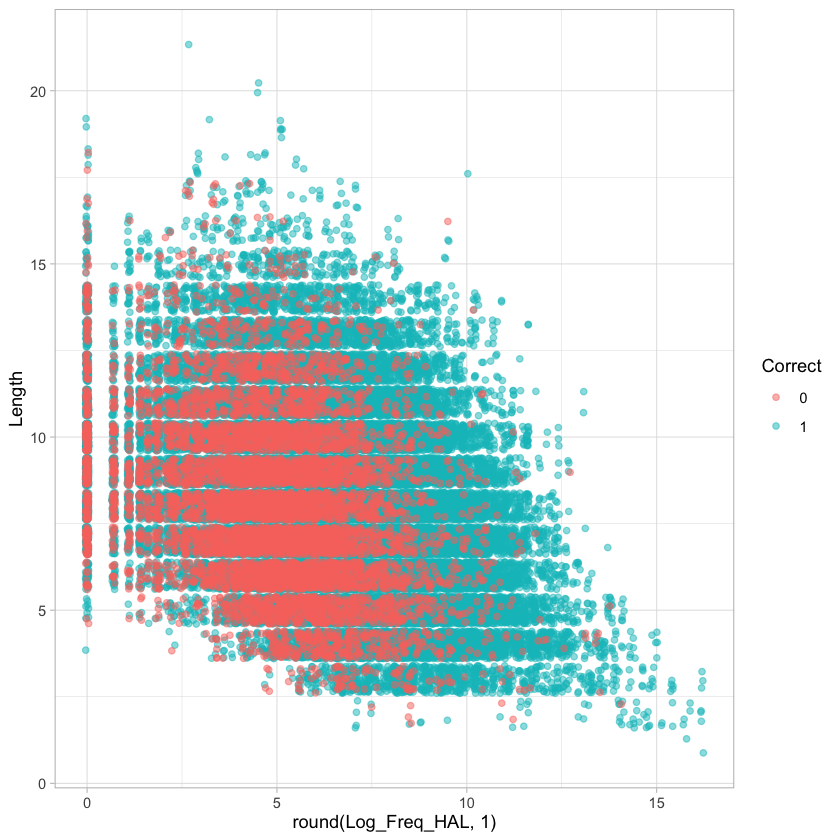

In [2]:
require(tidyverse) # Load the tidyverse package, if you haven't yet
dat$Correct <- as.factor(dat$Correct) # so that R knows that Correct is categorical, not numeric.

# plot the Correct / Incorrect clusters
ggplot(dat,aes(x=round(Log_Freq_HAL,1),y=Length,col=Correct)) + geom_point(position="jitter",alpha=0.5) + theme_light()

What do you observe about the "Correct" and "Incorrect" clusters?

> *Write your reponse here*
>
> On the first sight, correct responses (1, in blue) seemed to be outnumbering incorrect responses (0, in red). This may indicate that participants were generally quite accurate in their responses. Incorrect responses tend to concentrate in the left region of the plot, which are words that are relatively medium to longer in lenghth and lower in frequency. Move right twards the x axis, as the log frequency increases, incorrect responses seemed to become increasingly rare, and the remaining points are almosr entirely correct. In other words, shorter, more frequent words are almost answered exclusively correct. Correct responses tend to cluster around words that are higher in frequency, but span widely in terms of length, with a bigger variation on both length and frequency than incorrect responses. Moreover, the two clustrers overlap heavily, especially in the lower-mid-range of both length and frequency.

---
## 3. Logistic Regression: Fitting the model (3 points)

Fit a logistic regression model to the data using `Length`, `Log_Freq_HAL`, and their interaction to predict `Correct`. Use `glm()` to fit the model, and look at its output using `summary()`.

In [3]:
model <- glm(Correct ~ Length * Log_Freq_HAL, data = dat, family = binomial)

summary (model)


Call:
glm(formula = Correct ~ Length * Log_Freq_HAL, family = binomial, 
    data = dat)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.939996   0.115623  -8.130 4.30e-16 ***
Length               0.151266   0.012789  11.828  < 2e-16 ***
Log_Freq_HAL         0.394772   0.018762  21.041  < 2e-16 ***
Length:Log_Freq_HAL -0.010558   0.002202  -4.795 1.63e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 49809  on 70588  degrees of freedom
Residual deviance: 46563  on 70585  degrees of freedom
AIC: 46571

Number of Fisher Scoring iterations: 5


What can you conclude from this output? (a brief gist is fine)

> *Write your response here*
>
> All three predictors are statistically significant. Length has a positive coefficient (0.15), which means that longer words are associated with more resoponses answered correctly. This seemed counterintuitive to me at first since I expected perhaps longer words should be more difficult to answer correctly and thus would be a negative coefficient. Log_Freq_HAL also have a positive, and relatively higher coefficient (0.39), meaning that increasement of word frequency is positively associated with the liklihood for answering correctly. The interaction coefficient is negative (-0.011), indicating that the positive effet of length dimishes as frequency increases (and vice versa). Also, the model improves over the null model, shown from the reduction in deviation from 49809 to 46563.

---
## 4. Interpreting predictions from the model (4 points)

Finally, look at how well this logistic regression model does at predicting correctness. Use `predict()` and a threshold of 0.5 to generate predicted `Correct` values for each trial, then output a confusion matrix and overall accuracy for these predictions.

*Hint: see the Classifiers tutorial.*

In [4]:
# Set threshold
threshold <- 0.5

# Get predicted probabilities
dat$predicted_prob <- predict(model, type = "response")

# First make a list of "Incorrect"
dat$predicted_correct <- rep("Incorrect", nrow(dat))

# Then label predictions above threshold as "Correct"
dat$predicted_correct[dat$predicted_prob > threshold] <- "Correct"

# Convert actual Correct column to labels too
dat$actual_correct <- ifelse(dat$Correct == 1, "Correct", "Incorrect")

# Create confusion matrix
confusion_df <- data.frame(predicted = dat$predicted_correct, actual = dat$actual_correct)
table(confusion_df)

# Overall accuracy
accuracy <- sum(dat$predicted_correct == dat$actual_correct) / nrow(dat)
print(paste("Accuracy:", round(accuracy, 4)))

           actual
predicted   Correct Incorrect
  Correct     62566      7966
  Incorrect      44        13

[1] "Accuracy: 0.8865"


Did the model do well at predicting lexical decision correctness? Why or why not?

> *Write your response here*
>
> I think the model did not do too well at predicting lexical decision correctness. This is because although the model achieved an overall accuracy of 88.65%, I am indeed concerned about the high imbalance in the moidel's prediction, with far more correct cases than incorrect. Since in the data most cases are actually correct, I am worried that the model is only given out high accracy becasue of this. Because looking at the result, the model correctly identified almost all of the correct cases (making it having a high accuracy rate), but it also failed to identify almost all of the incorrect cases by labeling them as correct. More specifically, it labeled nearly everything as correct (62566+7966=70532 out of 70589 trials), and it almost always fails to identify incorrect responses (only 13 out of 7979 actual incorrect trials are accurately predicted). This model seemed to be pretty biased toward labeling answers as correct by predicting the majority class almost everytime. So its high accuracy may be a reflection of imbalanced data, so it is not super useful for detecting incorrect responses.

**DUE:** 11:59pm EST, March 3, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.
>